# Assignment 4: Neural Networks

---

## Task 1) Skip-grams

Tomas Mikolov's [original paper](https://arxiv.org/abs/1301.3781) for word2vec is not very specific on how to actually compute the embedding matrices.
Xin Ron provides a much more detailed [walk-through](https://arxiv.org/pdf/1411.2738.pdf) of the math, I recommend you go through it before you continue with this assignment.
Now, while the original implementation was in C and estimates the matrices directly, in this assignment, we want to use PyTorch (and autograd) to train the matrices.
There are plenty of example implementations and blog posts out there that show how to do it, I particularly recommend [Mateusz Bednarski's](https://towardsdatascience.com/implementing-word2vec-in-pytorch-skip-gram-model-e6bae040d2fb) version. Familiarize yourself with skip-grams and how to train them using pytorch.

### Data

Download the `theses.csv` data set from the `Supplemental Materials` in the `Files` section of our Microsoft Teams group.
This dataset consists of approx. 3,000 theses topics chosen by students in the past.
Here are some examples of the file content:

```
27.10.94;14.07.95;1995;intern;Diplom;DE;Monte Carlo-Simulation für ein gekoppeltes Round-Robin-System;
04.11.94;14.03.95;1995;intern;Diplom;DE;Implementierung eines Testüberdeckungsgrad-Analysators für RAS;
01.11.20;01.04.21;2021;intern;Bachelor;DE;Landessprachenerkennung mittels X-Vektoren und Meta-Klassifikation;
```

### Basic Setup

For the upcoming assignments on Neural Networks, we'll be heavily using [PyTorch](https://pytorch.org) as go-to Deep Learning library.
If you're not already familiar with PyTorch, now's the time to get started with it.
Head over to the [Basics](https://pytorch.org/tutorials/beginner/basics/intro.html) and gain some understanding about the essentials.
Before starting this assignment, make sure you've got PyTorch installed in your working environment. 
It's a quick setup, and you'll find all the instructions you need on the PyTorch website.
As always, you can use [NumPy](https://numpy.org) and [Pandas](https://pandas.pydata.org) for data handling etc.

*In this Jupyter Notebook, we will provide the steps to solve this task and give hints via functions & comments. However, code modifications (e.g., function naming, arguments) and implementation of additional helper functions & classes are allowed. The code aims to help you get started.*

---

In [1]:
# Dependencies
import numpy as np
import pandas as pd

### Prepare the Data

1.1 Spend some time on preparing the dataset. It may be helpful to lower-case the data and to filter for German titles. The format of the CSV-file should be:

```
Anmeldedatum;Abgabedatum;JahrAkademisch;Art;Grad;Sprache;Titel;Abstract
```

1.2 Create the vocabulary from the prepared dataset. You'll need it for the initialization of the matrices and to map tokens to indices.

1.3 Generate the training pairs with center word and context word. Which window size do you choose?

In [9]:
def load_theses_dataset(filepath):
    """Loads all theses instances and returns them as a dataframe."""
    ### YOUR CODE HERE
    
    return pd.read_csv(filepath, header=0, sep=";")
    
    ### END YOUR CODE

In [3]:
def preprocess(dataframe, language="DE"):
    """Preprocesses and tokenizes the given theses titles for further use."""
    ### YOUR CODE HERE

    titles = dataframe["Titel"].str.lower()

    tokenized = [title.split() for title in titles]

    return tokenized
    
    ### END YOUR CODE

In [4]:
def create_training_pairs(data, word2idx, window_size):
    """Creates training pairs based on skip-grams for further use."""
    ### YOUR CODE HERE
    
    training_pairs = []

    for sentence in data:
        # Map to indices
        indices = [word2idx[word] for word in sentence]

        # Skip-gram: treat each word as center word
        for center_word_pos in range(len(indices)):
            # Treat surrounding words as context words
            for w in range(-window_size, window_size + 1):
                context_word_pos = center_word_pos + w

                # Handle sentence boundaries and do not include center word
                if (context_word_pos < 0 or context_word_pos >= len(indices) or
                    context_word_pos == center_word_pos):
                    continue

                # Map to indices
                center_word_idx = indices[center_word_pos]
                context_word_idx = indices[context_word_pos]
                training_pairs.append((center_word_idx, context_word_idx))
    
    # It will be useful to have this as numpy array
    return np.array(training_pairs)
                
    ### END YOUR CODE

In [11]:
# dataframe = load_theses_dataset(...)
# tokenized_data = preprocess(dataframe)
# vocabulary = ...
# word2idx = ...
# idx2word = ...
# training_pairs = create_training_pairs(...)

dataframe = load_theses_dataset("data/theses2022.csv")

dataframe = dataframe[dataframe["Sprache"] == "DE"]

tokenized_data = preprocess(dataframe)

print(f"Num theses: {len(tokenized_data)}")

Num theses: 2982


In [12]:
vocab = set()
for s in tokenized_data:
    vocab.update(s)

vocab_size = len(vocab)

word2idx = {w: idx for (idx, w) in enumerate(sorted(vocab))}
idx2word = {idx: w for (idx, w) in enumerate(sorted(vocab))}

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 9337


In [13]:
window_size = 2

training_pairs = create_training_pairs(data=tokenized_data, word2idx=word2idx, window_size=window_size)

print(f"Num training pairs: {len(training_pairs)}")

Num training pairs: 119306


### Train and Analyze

2.1 Implement and train the word2vec model with your training data.

2.2 Implement a method to find the top-k similar words for a given word (token).

2.3 Analyze: What are the most similar words to "Konzeption", "Cloud" and "virtuelle"?

In [25]:
import torch
from torch.autograd import Variable
from torch.nn import Parameter
import torch.nn.functional as F
import random

In [27]:
### TODO: 2.1 Implement and train the word2vec model.

device = "mps"

### YOUR CODE HERE

embedding_dim = 5
num_epochs = 100
learning_rate = 0.01


def get_input_layer(word_idx):
    x = torch.zeros(vocab_size).float()
    x[word_idx] = 1.0
    return x


# Initialize matrices
W1 = Variable(torch.randn(embedding_dim, vocab_size).float(), requires_grad=True).to(device)
W2 = Variable(torch.randn(vocab_size, embedding_dim).float(), requires_grad=True).to(device)


batch_size = 128  # Set the mini-batch size

for epoch in range(1, num_epochs + 1):
    loss_val = 0

    # Shuffle training pairs each epoch (recommended)
    random.shuffle(training_pairs)

    for batch_start in range(0, len(training_pairs), batch_size):
        batch = training_pairs[batch_start:batch_start + batch_size]
        
        # Prepare mini-batch inputs and targets
        x_batch = []
        y_batch = []
        for data, target in batch:
            x_batch.append(get_input_layer(data))
            y_batch.append(target)

        x = Variable(torch.tensor(np.stack(x_batch))).float().to(device)  # Shape: (batch_size, input_dim)
        y_true = Variable(torch.tensor(y_batch)).long().to(device)        # Shape: (batch_size,)

        # Forward
        z1 = torch.matmul(x, W1.T)   # (batch_size, hidden_dim)
        z2 = torch.matmul(z1, W2.T)  # (batch_size, output_dim)
        log_softmax = F.log_softmax(z2, dim=1)  # Note dim=1 for batches
        loss = F.nll_loss(log_softmax, y_true)
        loss_val += loss.item() * x.size(0)  # Accumulate total loss properly

        # Retain grads if you want to inspect intermediate grads (optional)
        W1.retain_grad()
        W2.retain_grad()

        # Backward
        loss.backward()

        # Training step
        W1.data -= learning_rate * W1.grad.data
        W2.data -= learning_rate * W2.grad.data

        # Zero gradients
        W1.grad.data.zero_()
        W2.grad.data.zero_()

    # Log training progress
    if epoch % 5 == 0:
        print(f'Loss at epoch {epoch}: {loss_val/len(training_pairs)}')


# Train model for n epochs
# for epoch in range(1, num_epochs + 1):
#     loss_val = 0

#     for data, target in training_pairs:
#         x = Variable(get_input_layer(data)).float().to(device)
#         y_true = Variable(torch.from_numpy(np.array([target])).long()).to(device)

#         # Forward
#         z1 = torch.matmul(W1, x)
#         z2 = torch.matmul(W2, z1)
#         log_softmax = F.log_softmax(z2, dim=0)
#         loss = F.nll_loss(log_softmax.view(1,-1), y_true)
#         loss_val += loss.item()

#         W1.retain_grad()
#         W2.retain_grad()

#         # Backward
#         loss.backward()

#         # Training step
#         W1.data -= learning_rate * W1.grad.data
#         W2.data -= learning_rate * W2.grad.data

#         # Zero gradients
#         W1.grad.data.zero_()
#         W2.grad.data.zero_()

#     # Log training progress
#     if epoch % 5 == 0:    
#         print(f'Loss at epoch {epoch}: {loss_val/len(training_pairs)}')


### END YOUR CODE

Loss at epoch 5: 0.001079119001454868
Loss at epoch 10: 0.00046763424946931264
Loss at epoch 15: 0.0002940742842831961
Loss at epoch 20: 0.00021294665031324912
Loss at epoch 25: 0.0001663412598438587
Loss at epoch 30: 0.00013617063671431242
Loss at epoch 35: 0.00011507801556158999
Loss at epoch 40: 9.942674917568837e-05
Loss at epoch 45: 8.742357264437306e-05
Loss at epoch 50: 7.801704906634138e-05
Loss at epoch 55: 7.021942064985482e-05
Loss at epoch 60: 6.401763681663294e-05
Loss at epoch 65: 5.8695250132458006e-05
Loss at epoch 70: 5.4238853296971504e-05
Loss at epoch 75: 5.047858116348503e-05
Loss at epoch 80: 4.6911439262534683e-05
Loss at epoch 85: 4.405540700239333e-05
Loss at epoch 90: 4.1343763802002976e-05
Loss at epoch 95: 3.9070310469983425e-05
Loss at epoch 100: 3.702221586164328e-05


In [14]:
### TODO: 2.2 Implement a method to find the top-k similar words.

### YOUR CODE HERE

Wmat = W1.detach()

def sim_fn(u, v):
  """Computes the cosine similarity for two given embeddings."""
  return torch.dot(u, v) / (torch.norm(u) * torch.norm(v))


def get_top_k(word, vocabulary, word2idx, k=3):
  """Gets the top-k words for a given word."""
  word_idx = word2idx[word]
  word_emb = torch.matmul(Wmat, get_input_layer(word_idx))

  results = []
  for cand in vocabulary:
    if cand == word:
      continue

    cand_idx = word2idx[cand]
    cand_emb = torch.matmul(Wmat, get_input_layer(cand_idx))
    similarity = sim_fn(word_emb, cand_emb)
    results.append((similarity, word, cand))

  top_k_results = sorted(results, key=lambda x: x[0], reverse=True)[:k]
  return top_k_results

### END YOUR CODE

NameError: name 'W1' is not defined

In [11]:
### TODO: 2.3 Find the most similar words for "Konzeption", "Cloud" and "virtuelle".

### YOUR CODE HERE

for word in ["Konzeption", "Cloud", "virtuelle"]:
    word = word.lower()

    top_k = get_top_k(word, vocabulary=vocab, word2idx=word2idx, k=3)

    print(f"Input word: {word}")
    for cand in top_k:
        print(f"\t{cand}")
    print()

### END YOUR CODE

Input word: konzeption
	(tensor(0.9931), 'konzeption', 'entwurf')
	(tensor(0.9891), 'konzeption', 'anforderungen.')
	(tensor(0.9878), 'konzeption', 'kommunikations-')

Input word: cloud
	(tensor(0.9917), 'cloud', 'umsatzsteuer-id')
	(tensor(0.9917), 'cloud', 'systeme?')
	(tensor(0.9909), 'cloud', 'abbildungsmöglichkeiten')

Input word: virtuelle
	(tensor(0.9935), 'virtuelle', 'modellbildungsprozess')
	(tensor(0.9921), 'virtuelle', 'spring-framework')
	(tensor(0.9917), 'virtuelle', 'techniken')



### Play with the Embeddings

3.1 Use the computed embeddings: Can you identify the most similar theses for some examples?

3.2 Visualize the embeddings for a subset of theses using [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html). You can use [Scikit-Learn](https://scikit-learn.org/stable/) and [Matplotlib](https://matplotlib.org) or [Seaborn](https://seaborn.pydata.org).

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
### TODO: 3.1 Compute the embeddings for the theses and transform with TSNE.

### YOUR CODE HERE

def embed_word(word, W, word2idx):
    """Embeds the given word."""
    return torch.matmul(W, get_input_layer(word2idx[word]))


# Get top nouns
top_50_nouns_df = dataframe["Titel"].str.split(expand=True).stack() \
    .value_counts() \
    .filter(regex=r'^[A-Z]')[:50].to_frame()

top_50_nouns_embs = [embed_word(x.lower(), Wmat, word2idx) for x in top_50_nouns_df.index.values]
top_50_nouns_embs = torch.stack(top_50_nouns_embs, dim=0)

print(f"Top 50 nouns shape: {top_50_nouns_embs.shape}")


# TSNE for visualization
tsne = TSNE(n_components=2, verbose=1)
tsne_results = tsne.fit_transform(top_50_nouns_embs)
tsne_results

top_50_nouns_df['tsne-1'] = tsne_results[:,0]
top_50_nouns_df['tsne-2'] = tsne_results[:,1]

### END YOUR CODE

Top 50 nouns shape: torch.Size([50, 5])
[t-SNE] Computing 49 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.178s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.370800
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.937080
[t-SNE] KL divergence after 800 iterations: 0.100936


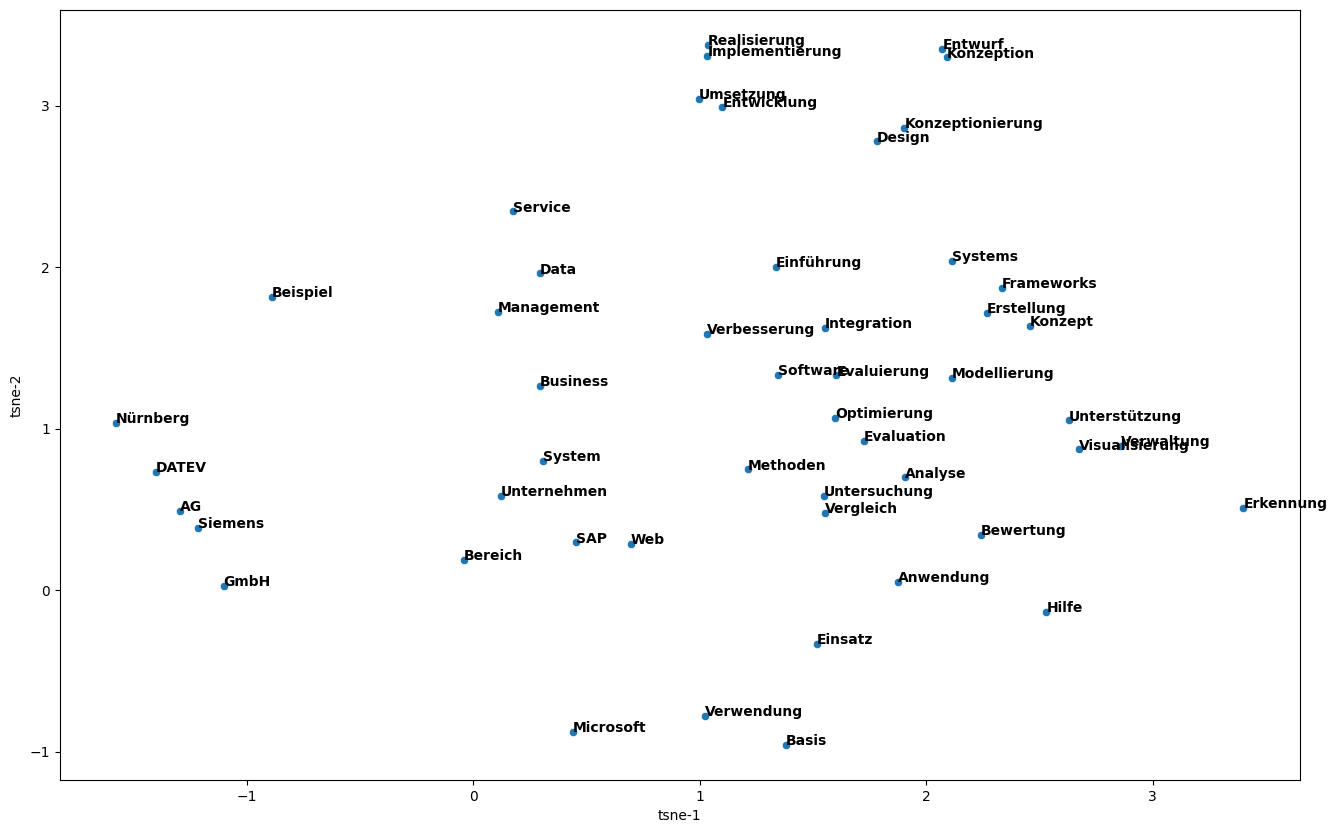

In [14]:
### TODO: 3.2 Visualize the samples in the 2D space.

### YOUR CODE HERE

plt.figure(figsize=(16,10))
sns.scatterplot(
    x="tsne-1",
    y="tsne-2",
    data=top_50_nouns_df,
    legend="full"
)
for line in range(top_50_nouns_df.shape[0]):
     plt.text(
        top_50_nouns_df.iloc[line]['tsne-1'],
        top_50_nouns_df.iloc[line]['tsne-2'], 
        top_50_nouns_df.index[line], 
        horizontalalignment='left', 
        size='medium',
        color='black',
        weight='semibold')

### END YOUR CODE

In [15]:
### We can also compute the similarities between entire titles

def embed_title(words, W, word2idx):
    """Computes the title embedding with mean pooling."""
    word_embs = [embed_word(word.lower(), W, word2idx) for word in words]
    word_embs = torch.stack(word_embs, dim=0)
    title_emb = torch.mean(word_embs, dim=0)
    return title_emb


# Compute the title level embeddings
titles_embs = [embed_title(title, Wmat, word2idx) for title in tokenized_data]
titles_embs = torch.stack(titles_embs, dim=0)

# Get some random titles for comparison
titles_subset_idx = np.random.choice(range(len(titles_embs)), size=5, replace=False)


# Get the most similar titles
for title_idx in titles_subset_idx:
    title = " ".join(tokenized_data[title_idx])
    title_emb = titles_embs[title_idx]

    results = []
    for cand_idx in range(len(titles_embs)):
        if cand_idx == title_idx:
            continue

        cand_title = " ".join(tokenized_data[cand_idx])
        cand_title_emb = titles_embs[cand_idx]

        sim_score = sim_fn(title_emb, cand_title_emb)
        sim_score = round(sim_score.item(), 3)

        results.append((sim_score, cand_title))

    results_top_k = sorted(results, key=lambda x: x[0], reverse=True)[:3]

    print(f"Input title: {title}")
    for cand in results_top_k:
        print(f"\t{cand}")
    print()

Input title: konzeption und implementierung einer auf xsl-templates basierenden dokumentaufbereitung für unterschiedliche endgeräte
	(0.996, 'prototypische implementierung eines interaktiven analyse-dashboards auf basis des referenzierten datev-jahresabschlusses')
	(0.992, 'entwicklung eines gestenunterstützten natürlichsprachlichen dialogs mit einem humanoiden roboter')
	(0.991, 'konzeption und entwicklung einer suchfunktion für die online-filmeplattform "ohmrolle" basierend auf microsoft silverlight')

Input title: entwurf und realisierung eines monitors und debuggers für einen digitalen signalprozessor
	(0.999, 'konzeption und prototypische implementierung einer testkette für automatische abnahmetests innerhalb einer verteilten anwendungsumgebung')
	(0.998, 'konzeption und auswahl eines management-informations-systems für ein ingenieur-büro')
	(0.998, 'entwicklung und implementierung eines konzepts für sicheres speichern von drm-objekten')

Input title: konzeption und implementierun